In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

from torchmetrics import Accuracy

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
SELECTED_CLASSES = [
    52, 53, 54,    # snake
    321, 322, 323, # butterfly
    952, 953, 954, # fruit
]


CLASS_GROUP_MAPPING = {
    52:0,53:0,54:0,
    321:1,322:1,323:1,
    952:2,953:2,954:2
}

NUM_GROUPS = len(set(CLASS_GROUP_MAPPING.values()))

print(f"We have {NUM_GROUPS} groups")


def ano():
    mapping = dict()
    for ix, cix in enumerate(SELECTED_CLASSES):

        gix = CLASS_GROUP_MAPPING[cix]
        print(f"[ix={ix}]: cix={cix:3d} (mapped to {gix})")
        mapping[ix] = gix
    return mapping
    
LOCAL_LABEL_MAPPING = ano()
LOCAL_LABEL_MAPPING

We have 3 groups
[ix=0]: cix= 52 (mapped to 0)
[ix=1]: cix= 53 (mapped to 0)
[ix=2]: cix= 54 (mapped to 0)
[ix=3]: cix=321 (mapped to 1)
[ix=4]: cix=322 (mapped to 1)
[ix=5]: cix=323 (mapped to 1)
[ix=6]: cix=952 (mapped to 2)
[ix=7]: cix=953 (mapped to 2)
[ix=8]: cix=954 (mapped to 2)


{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2}

In [6]:
class ImageNetMixed(datasets.ImageNetSuperClass):
    selected_classes = SELECTED_CLASSES

In [7]:
dataset = ImageNetMixed()

In [8]:
ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

We have 11700 images in classes [52, 53, 54, 321, 322, 323, 952, 953, 954]


preparing `ImageNetMixed` samples: 100%|████████████| 11700/11700 [00:00<00:00, 2522532.99it/s]


We have 450 images in classes [52, 53, 54, 321, 322, 323, 952, 953, 954]


preparing `ImageNetMixed` samples: 100%|█████████████████| 450/450 [00:00<00:00, 604173.11it/s]


In [9]:
MODEL_NAME = "imagenet-vgg16-tv"

MAIN_LAYER = "features.23"
# MODEL_NAME = "imagenet-resnet50-tv"

In [10]:
def extract_features(model_name):
    
    arr_feats = []
    arr_targets = []
    
    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)

    model.to(device)
    nclasses = len(dataset.selected_classes)
    
    count = 0
    with torch.no_grad():
        
        for count, (x, _) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            feat = model(x).cpu().numpy()
            arr_feats.append(feat)
            arr_targets.append(np.argmax(feat, axis=1))
            
#             if count > 1:
#                 break
                
            count += 1

    arr_feats = np.vstack(arr_feats)
    arr_targets = np.concatenate(arr_targets)
    

    ncols = nclasses
    nrows = 1
    
    assert arr_feats.shape[1] == nclasses
    
    global_mean = np.mean(arr_feats)
    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(model_name, y=1.1)
    vmin = np.min(arr_feats)
    vmax = np.max(arr_feats)
    for class_ix in tqdm(range(nclasses)):
        plt.subplot(1, ncols, class_ix+1)
        
        class_logits =   arr_feats[
                arr_targets == class_ix,
                class_ix
            ]
        plt.hist(class_logits, alpha=0.5)
        
        plt.title(f"f{class_ix} (#{len(class_logits)})")
        
        class_mean = np.mean(class_logits)
        
        plt.axvline(
            global_mean, 
            ls="--",
            label=f"global ($\Delta$={class_mean - global_mean:.2f})"
        )
        plt.axvline(
            np.mean(class_logits), ls="-", label=f"class={class_mean:.2f}",
        )
        plt.xlim([vmin, vmax])
        plt.legend()

            
# extract_features("imagenet-vgg16-tv");

In [11]:
def last_layer_rewriting(model_name, rewriting):
    
    arr_logits = []
    arr_feats = []
    arr_targets = []
    
    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
    model.to(device)
    
    if not rewriting:
        print(f"[rewriting={rewriting}] Return Original Model")
        return model
    
    with torch.no_grad():
        
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            logits = model(x).cpu().numpy()
            arr_logits.append(logits)
            arr_targets.append(np.argmax(logits, axis=1))

#             if count > 1:
#                 break
    
    weights = model.__last_layer.weight.detach().cpu().numpy()
    
    acc_before = accuracy_with_group(
        model,
        dataloader=datasets.build_dataloader(ds_val, shuffle=False),
        num_groups=NUM_GROUPS,
        device=device,
    )

    normed_weights = weights / np.linalg.norm(weights, axis=1, keepdims=True)
    
    print(f"model_name={model_name}")
    if "vgg" in model_name:
        model.classifier[6] = torch.nn.Identity()
    elif "resnet" in model_name:
        model.fc = torch.nn.Identity()
    else:
        raise
    

    with torch.no_grad():
        
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            feat = model(x).cpu().numpy()
            arr_feats.append(feat)
#             if count > 1:
#                 break

    arr_logits = np.vstack(arr_logits)

    arr_feats = np.vstack(arr_feats)
    arr_targets = np.concatenate(arr_targets)
    
    
    arr_w = []
    arr_b = []
        
    for class_ix in tqdm(sorted(np.unique(arr_targets))):
        cond = arr_targets == class_ix
        arr_class_feats = arr_feats[cond, :]
        _, eigvecs = np.linalg.eigh(arr_class_feats.T @ arr_class_feats)
        pc1 = eigvecs[:, -1]
        pc1 = pc1 / np.linalg.norm(pc1)
        
        proj = np.mean(arr_class_feats @ pc1) 
        if proj < 0:
            pc1 = -pc1
            
        arr_w.append(pc1)
        
        bias = np.mean(arr_feats @ pc1 - arr_logits[:, class_ix])
        arr_b.append(bias)
        
    
    out_feats, in_feats = normed_weights.shape
    new_layer = torch.nn.Linear(out_features=out_feats, in_features=in_feats)
    new_layer.weight = torch.nn.Parameter(
        torch.from_numpy(np.stack(arr_w))
    )
    
    new_layer.bias = torch.nn.Parameter(
        torch.tensor(arr_b)
    )
    
    if "vgg" in model_name:
        model.classifier[6] = new_layer
    elif "resnet" in model_name:
        model.fc = new_layer
    else:
        raise

    new_layer.to(device)
    
    acc_after = accuracy_with_group(
        model,
        dataloader=datasets.build_dataloader(ds_val, shuffle=False),
        num_groups=NUM_GROUPS,
        device=device,
    )
    
    print(f"acc_before={acc_before}  : acc_after={acc_after}")
    
    return model
            


teacher = last_layer_rewriting(MODEL_NAME, rewriting=False);

[rewriting=False] Return Original Model


In [12]:
def get_winning_logits(model):
    with torch.no_grad():

        arr_logits = []
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            logits = model(x).cpu()

            topk = torch.topk(logits, k=1, dim=1)
            winning_logits = topk.values
            arr_logits.extend(winning_logits.numpy().tolist())
    return np.array(arr_logits)


def ano():
    arr_logits = get_winning_logits(teacher)

    plt.title(MODEL_NAME)
    plt.hist(arr_logits)
    plt.axvline(np.mean(arr_logits))
# ano()

In [13]:
def transform_class_to_group_ix(y):
    ynew = torch.zeros_like(y)

    assert len(y.shape) == 1
    
    for i in range(y.shape[0]):
        ynew[i] = LOCAL_LABEL_MAPPING[int(y[i])]

    return ynew

def combine_logits(logits):
    n, C = logits.shape
    new_logits = torch.zeros(n, NUM_GROUPS).to(logits.device)
    for i in range(n):
        for j in range(C):
            gix = LOCAL_LABEL_MAPPING[j]
            new_logits[i, gix] += logits[i, j]

    return new_logits

    

def accuracy_with_group(
    model,
    dataloader,
    num_groups: int,
    device: str,
    verbose=False,
):
    """_summary_

    Args:
        model (nn.Module): _description_
        dataloader (DataLoader): _description_
        num_classes (int): _description_
        device (str): _description_
        verbose (bool, optional): _description_. Defaults to False.

    Returns:
        acc: torch.Tensor
        xent: torch.Tensor
    """
    model.eval()

    metric_acc = Accuracy(task="multiclass", num_classes=num_groups)

    for x, y in tqdm(
        dataloader, desc="computing group accuracy for selected claseses", disable=not verbose
    ):
        logits = model(x.to(device)).cpu()
        metric_acc.update(
            combine_logits(logits), 
            transform_class_to_group_ix(y)
        )

    return float(metric_acc.compute())


teacher_acc = accuracy_with_group(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_groups=NUM_GROUPS,
    device=device,
)
teacher_acc

0.995555579662323

In [14]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
LOCAL_LABEL_MAPPING

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2}

In [16]:
def select_winning_group_logits(logits):
    group_logits = combine_logits(logits)

    
    n, C = logits.shape

    winning_groups = torch.argmax(group_logits, dim=1)

    one_hots = torch.zeros(n, C)

    for i in range(n):
        for j in range(C):
            if LOCAL_LABEL_MAPPING[j] == winning_groups[i]:
                one_hots[i, j] = 1

    # return logits.clone() * one_hots.to(logits.device) * (logits > 0)
    return one_hots.to(logits.device)

@torch.no_grad()
def sanity_check():
    
    output = select_winning_group_logits(
        torch.tensor([
            [20, 30, -5, 0, 2, 1, 8, 7, 9],
            [20, 30, -5, 0, 2, 1, 800, 700, 900],
        ])
    )

    np.testing.assert_allclose(
        output.numpy(),
        np.array(
            [
                [20, 30, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 800, 700, 900],
            ]
        )
    )
    print("sanity check: passed!")
# sanity_check()

In [17]:
class WinningGroupEvidence(attributors.LogitModifier):
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        
        logits = logits.clone()
        
        return  select_winning_group_logits(logits)

    def __str__(self) -> str:
        return "winninggroup"

def make_attributor_for(
    model,
    input_statistics,
    gamma,
    epsilon,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    if isinstance(model, models.resnet.resnet.ResNet):
        canonizers = [ResNetCanonizer()]
    else:
        canonizers = []

    print(f"Instantiating EpsilonGammaBox(gamma={gamma}, eps={epsilon})")

    composite = EpsilonGammaBox(low=low, high=high, canonizers=canonizers, gamma=gamma, epsilon=epsilon)

    print(f"Composite={composite}")
    attributor = Gradient(model=model, composite=composite)


    return attributor


    
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    
    with make_attributor_for(model, dataset.input_statistics, gamma=gamma, epsilon=eps) as attributor:
        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad

                output_dimensions = act.shape[1:]

                # todo: check this with Gregoire again!
                ctx = torch.where(act.abs() > 0, rel / act, 0)

                assert torch.allclose(act * ctx, rel)

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx





def get_act_ctx(model, dataset, layer, gamma=0.25, eps=1e-6, verbose=False):

    logit_modifier = WinningGroupEvidence()
    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )


_arr_act, _arr_ctx = get_act_ctx(
    last_layer_rewriting(MODEL_NAME, rewriting=False),
    dataset,
    layer=MAIN_LAYER, 
    verbose=False
)

[rewriting=False] Return Original Model
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)
Composite=<zennit.composites.EpsilonGammaBox object at 0x7fd3a21cfd30>


100%|████████████████████████████████████████████████████████| 183/183 [02:12<00:00,  1.38it/s]


In [18]:
@torch.no_grad()
def decorrelate(A: torch.Tensor) -> torch.Tensor:
    # U_ = U @ (U.T @ U)^{-1/2}
    # ref: Hyvärinen et al. (2003), Independent Component Analysis, eq 6.37

    S = A.T @ A
    # somehow, for some classes (e.g. basketball at nfnet-f0's stage1),
    # the eigenvalue decomposition fails if using float.
    # Using double makes it more stable but slightly decreases the speed.
    # See: https://gist.github.com/p16i/4a37e10230c016fcde6c0e571c9ae010
    D, E = torch.linalg.eigh(S.double())
    D = D.float()
    E = E.float()

    inv = E @ torch.diag(1 / (torch.pow(D, 0.5))) @ E.T

    return A @ inv

In [19]:
def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc = accuracy_with_group(
                model,
                dataloader=dl,
                num_groups=NUM_GROUPS,
                device=device,
        )

    finally:
        hook.remove()
        del UUT
    return acc

In [20]:

def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        
        return out2

    return UUT, do 

In [21]:
from collections import OrderedDict

In [22]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [23]:
from torchvision.models import VGG, ResNet

In [24]:
def flatten_layers(model):
    # build all layer names

    if isinstance(model, VGG):
    
        layers = []
        for lix, layer in enumerate(model.features.children()):
            slug = f"features:{lix}"
            
            layers.append((slug, layer))
        
        layers.append(("avgpool", model.avgpool))
        layers.append(("flatten", torch.nn.Flatten(start_dim=1)))
    
        
        for lix, layer in enumerate(model.classifier.children()):
            slug = f"classifier:{lix}"
            
            layers.append((slug, layer))

    elif isinstance(model, ResNet):
        layers = [
            ("conv1", model.conv1),
            ("bn1", model.bn1),
            ("relu", model.relu),
            ("maxpool", model.maxpool),
            ("layer1", model.layer1),
            ("layer2", model.layer2),
            ("layer3", model.layer3),
            ("layer4", model.layer4),
            ("avgpool", model.avgpool),
            ("flatten", torch.nn.Flatten(start_dim=1)),
            ("fc", model.fc)
        ]
        
    
    return torch.nn.Sequential(OrderedDict(layers))

@torch.no_grad()
def sanity_check():

    new_module = flatten_layers(teacher)

    x = torch.rand(8, 3, 224, 224).to(device)
    expected = teacher(x).detach().cpu().numpy()
    actual = new_module(x).detach().cpu().numpy()

    np.testing.assert_allclose(actual, expected)
    print("sanity check: passed!")
    return new_module
sanity_check()

sanity check: passed!


Sequential(
  (features:0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:1): ReLU(inplace=True)
  (features:2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:3): ReLU(inplace=True)
  (features:4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:6): ReLU(inplace=True)
  (features:7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:8): ReLU(inplace=True)
  (features:9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:11): ReLU(inplace=True)
  (features:12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:13): ReLU(inplace=True)
  (features:14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (featur

In [25]:
def get_module_names(flatten_model):
    name = list(map(lambda n: n[0], flatten_model.named_modules()))

    if isinstance(teacher, VGG):
        
        return list(filter(lambda x: x, name))
    elif isinstance(teacher, ResNet):
        return list(filter(lambda x: "." not in x and x, name))
get_module_names(flatten_layers(teacher))

['features:0',
 'features:1',
 'features:2',
 'features:3',
 'features:4',
 'features:5',
 'features:6',
 'features:7',
 'features:8',
 'features:9',
 'features:10',
 'features:11',
 'features:12',
 'features:13',
 'features:14',
 'features:15',
 'features:16',
 'features:17',
 'features:18',
 'features:19',
 'features:20',
 'features:21',
 'features:22',
 'features:23',
 'features:24',
 'features:25',
 'features:26',
 'features:27',
 'features:28',
 'features:29',
 'features:30',
 'avgpool',
 'flatten',
 'classifier:0',
 'classifier:1',
 'classifier:2',
 'classifier:3',
 'classifier:4',
 'classifier:5',
 'classifier:6']

In [26]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [27]:
MODEL_NAME, MAIN_LAYER

('imagenet-vgg16-tv', 'features.23')

In [28]:
CACHE_STORE = dict()

def get_act_ctx_for_basis(model_rewritten):
    
    if model_rewritten in CACHE_STORE:
        print(f"rewritten={model_rewritten}: get from cache")
        return CACHE_STORE[model_rewritten]
    
    CACHE_STORE[model_rewritten] = get_act_ctx(
        last_layer_rewriting(MODEL_NAME, rewriting=model_rewritten),
        dataset,
        layer=MAIN_LAYER, 
        verbose=False
    )

    return CACHE_STORE[model_rewritten]

get_act_ctx_for_basis(False)

[rewriting=False] Return Original Model
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)
Composite=<zennit.composites.EpsilonGammaBox object at 0x7fd3a21ccf70>


100%|████████████████████████████████████████████████████████| 183/183 [02:13<00:00,  1.37it/s]


(array([[0.       , 0.       , 2.5971334, ..., 0.       , 0.       ,
         0.       ],
        [0.       , 0.       , 5.303115 , ..., 0.       , 0.       ,
         0.       ],
        [4.3643913, 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        ...,
        [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
         0.       ],
        [3.978034 , 8.701352 , 0.       , ..., 0.6997872, 3.1348915,
         0.       ],
        [0.       , 4.4398956, 0.       , ..., 0.       , 5.1442037,
         0.       ]], dtype=float32),
 array([[ 0.0000000e+00,  0.0000000e+00,  6.8950076e-06, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  4.3177028e-05, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-1.3508562e-05,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 

In [29]:
# get_act_ctx_for_basis(True)

['pca', 'prca', 'prcasortabs']


  0%|                                                                    | 0/6 [00:00<?, ?it/s]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache


 17%|██████████                                                  | 1/6 [00:11<00:56, 11.24s/it]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache


...

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache


 83%|██████████████████████████████████████████████████          | 5/6 [00:56<00:11, 11.41s/it]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prca; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
rewritten=False: get from cache


100%|████████████████████████████████████████████████████████████| 6/6 [01:08<00:00, 11.40s/it]


,layer,k,basis_name,acc_val
0,features.23,1,pca,0.435556
1,features.23,1,prca,0.333333
2,features.23,1,prcasortabs,0.333333
3,features.23,2,pca,0.540000
4,features.23,2,prca,0.384444
5,features.23,2,prcasortabs,0.384444
6,features.23,4,pca,0.675556
7,features.23,4,prca,0.522222
8,features.23,4,prcasortabs,0.522222
9,features.23,8,pca,0.848889


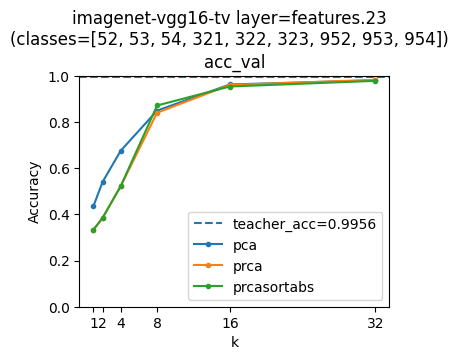

In [30]:
import matplotlib as mpl


def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    dl_train = datasets.build_dataloader(ds_train, shuffle=False)    
    
    rows = []
    print(arr_bases)
    for k in tqdm(arr_ks):
        for basis_name in arr_bases:
            Uk = estimate_basis(
                layer=layer,
                basis_name=basis_name, 
                k=k
            )
            acc_val = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_val)

            rows.append(
                    dict(
                        layer=layer, k=k, 
                        basis_name=basis_name,
                        acc_val=acc_val,
#                         acc_train=acc_train
                    )
            )
    

    df = pd.DataFrame(rows)

    return df



def estimate_basis(layer, basis_name, k):
    print(f"basis_name={basis_name}; layer={MAIN_LAYER}; model_name={MODEL_NAME}")
    if basis_name == "pca":
        arr_act, _ = get_act_ctx_for_basis(model_rewritten=False)
        _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
        U = np.flip(pca_eigvecs, axis=1).copy()
        return U[:, :k].copy()
    elif basis_name == "prca":
        arr_act, arr_ctx = get_act_ctx_for_basis(model_rewritten=False)

        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-eigvals)

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()
    elif basis_name == "prcasortabs":
        arr_act, arr_ctx = get_act_ctx_for_basis(model_rewritten=False)

        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()
    
    elif basis_name == "prcasortabs:llrw":

        arr_act, arr_ctx = get_act_ctx_for_basis(model_rewritten=True)

        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()

    else:
        raise NotImplementedError(f"basis_name={basis_name}")

def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases=[
        "pca",
        "prca",
        "prcasortabs", 
        # "prcasortabs:llrw",
    ],
    arr_ks=[1,2, 4, 8, 16, 32],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
        if name == "pca":
            return "PCA"
        elif "prcaopt:" in name:
            _, slug = name.split(":")
            return f"PCA-LH:{slug}"
        else:
            raise
            
    def ls(name):
        if name == "prcasortabs-penu":
            return "--"
        else:
            return "-"

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prcaopt":
            return "red"
        else:
            return None
            

    cols = [
#         "acc_train", 
        "acc_val"
    ]
    ncols = len(cols)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(
        f"{MODEL_NAME} layer={layer}\n(classes={dataset.selected_classes})", 
        y=1.1
    )

    for cix, col in enumerate(cols):
        plt.subplot(1, ncols, cix+1)
        plt.title(col)
        plt.axhline(teacher_acc, ls="--", label=f"teacher_acc={teacher_acc:.4f}")
        for nix, name in enumerate(df.basis_name.unique()):
            _df = df[df.basis_name == name]
            
            plt.plot(
                _df.k, 
                _df[col],
                label=alias(name),
                ls=ls(name),
                marker=".",
#                 color=color(name) if name in ["pca", "prcaopt"] else colors((nix+0.1)/nbases) 
            )
    
        plt.ylim([0, 1])
        plt.legend()
        plt.ylabel("Accuracy"); plt.xlabel("k")
        plt.xticks(df.k.unique())
    
    return df
    
estimate_rank_k_accuracies(model=teacher, dataset=dataset, layer=MAIN_LAYER)

In [31]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-08 04:45:59.704800
